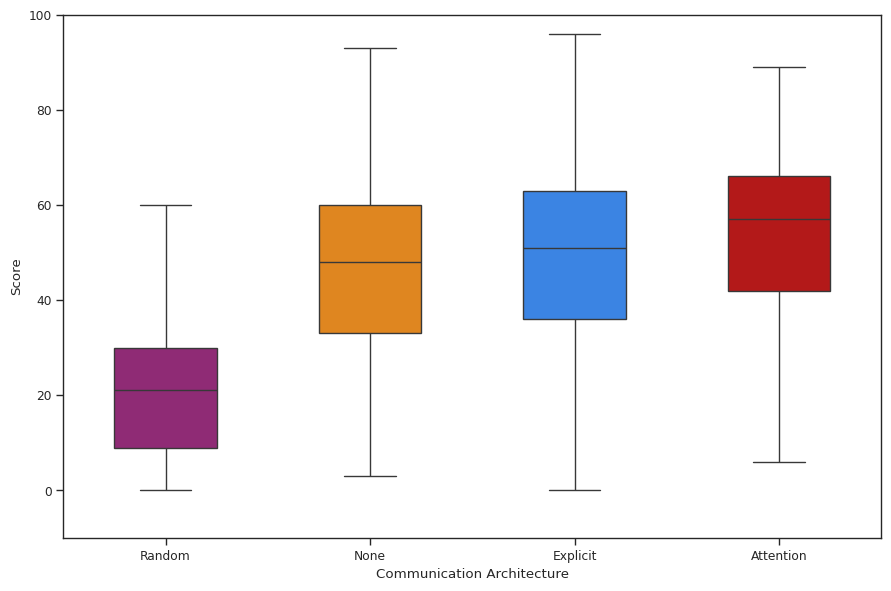

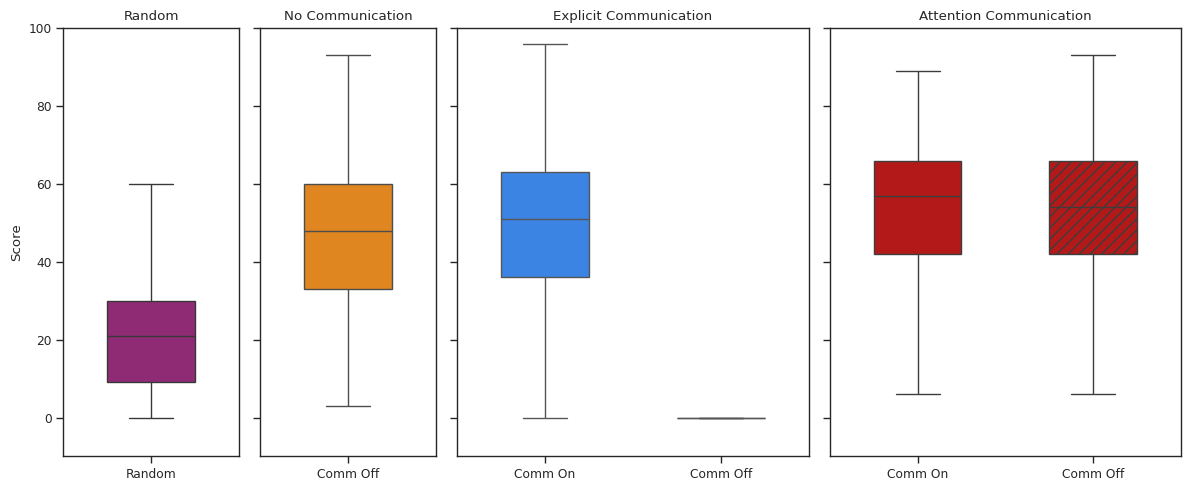

--- Statistical Significance Results ---
Explicit vs Attention (Global): p = 0.0000
None vs Explicit (Global): p = 0.0393
None vs Attention (Global): p = 0.0000
Explicit Ablation (On vs Off): p = 0.0000
Attention Ablation (On vs Off): p = 0.0789

--- Average Inference Time (ms) ---
None: 0.26 ms
Explicit: 0.24 ms
Attention: 0.38 ms
None vs Explicit Inference Time: p = 0.0000
None vs Attention Inference Time: p = 0.0000
Explicit vs Attention Inference Time: p = 0.0000


In [4]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from scipy.stats import ttest_ind, kruskal
from matplotlib.patches import Patch

# Professional Paper Setting
PALETTE = ['#FF8800', '#1F80FF', '#CC0000', '#A01A7D', '#D55E00']
sns.set_theme(style="ticks", context="paper", palette=PALETTE)

# 1. Load Data
none_none = pd.read_csv('none_none_1_0.csv')
copy_copy = pd.read_csv('copy_copy_1_0.csv')
copy_none = pd.read_csv('copy_none_1_0.csv')
attn_attn = pd.read_csv('attention_attention_1_0.csv')
attn_none = pd.read_csv('attention_none_1_0.csv')
random_random = pd.read_csv('random_1_0.csv')

# --- FIGURE 1: GLOBAL COMPARISON ---
fig, ax = plt.subplots(figsize=(9, 6))
global_df = pd.DataFrame({
    "Architecture": ["Random"] * len(random_random['score_red']) + ["None"] * len(none_none['score_red']) + ["Explicit"] * len(copy_copy['score_red']) + ["Attention"] * len(attn_attn['score_red']),
    "Score": pd.concat([random_random['score_red'], none_none['score_red'], copy_copy['score_red'], attn_attn['score_red']], ignore_index=True)
})

sns.boxplot(
    data=global_df,
    x="Architecture",
    y="Score",
    hue="Architecture",
    showfliers=False,
    width=0.5,
    palette=[PALETTE[3], PALETTE[0], PALETTE[1], PALETTE[2]],
    legend=False,
    ax=ax
)

ax.set_ylabel('Score')
ax.set_xlabel('Communication Architecture')
ax.set_ylim(-10, 100)
plt.tight_layout()
plt.show()

# --- FIGURE 2: ABLATION STUDY (NONE NARROW ON THE LEFT) ---
fig, (ax3, ax0, ax1, ax2) = plt.subplots(
    1, 4, figsize=(12, 5), sharey=True,
    gridspec_kw={"width_ratios": [0.5, 0.5, 1.0, 1.0]}
)

# Random (narrow, left)
df_random = pd.DataFrame({
    "Execution": ["Random"] * len(random_random['score_red']),
    "Score": random_random['score_red'].reset_index(drop=True)
})
sns.boxplot(
    data=df_random,
    x="Execution",
    y="Score",
    hue="Execution",
    order=["Random"],
    ax=ax3,
    showfliers=False,
    width=0.5,
    dodge=False,
    palette={"Random": PALETTE[3]},
    legend=False
)
ax3.set_title('Random')
ax3.set_xlabel('')
ax3.set_ylabel('Score')
ax3.set_ylim(-10, 100)

# No Communication (narrow, left)
df_none = pd.DataFrame({
    "Execution": ["Comm Off"] * len(none_none['score_red']),
    "Score": none_none['score_red'].reset_index(drop=True)
})
sns.boxplot(
    data=df_none,
    x="Execution",
    y="Score",
    hue="Execution",
    order=["Comm Off"],
    ax=ax0,
    showfliers=False,
    width=0.5,
    dodge=False,
    palette={"Comm Off": PALETTE[0]},
    legend=False
)
ax0.set_title('No Communication')
ax0.set_xlabel('')
ax0.set_ylabel('Score')
ax0.set_ylim(-10, 100)

# Explicit: Comm On vs Comm Off
df_copy = pd.DataFrame({
    "Execution": ["Comm On"] * len(copy_copy['score_red']) + ["Comm Off"] * len(copy_none['score_red']),
    "Score": pd.concat([copy_copy['score_red'], copy_none['score_red']], ignore_index=True)
})
sns.boxplot(
    data=df_copy,
    x="Execution",
    y="Score",
    hue="Execution",
    order=["Comm On", "Comm Off"],
    ax=ax1,
    showfliers=False,
    width=0.5,
    dodge=False,
    palette={"Comm On": PALETTE[1], "Comm Off": PALETTE[1]},
    legend=False
)
if len(ax1.patches) >= 2:
    ax1.patches[1].set_hatch('///')
    # ax1.patches[1].set_edgecolor('white')

ax1.set_title('Explicit Communication')
ax1.set_xlabel('')
ax1.set_ylabel('')
ax1.set_ylim(-10, 100)

# Attention: Comm On vs Comm Off
df_attn = pd.DataFrame({
    "Execution": ["Comm On"] * len(attn_attn['score_red']) + ["Comm Off"] * len(attn_none['score_red']),
    "Score": pd.concat([attn_attn['score_red'], attn_none['score_red']], ignore_index=True)
})
sns.boxplot(
    data=df_attn,
    x="Execution",
    y="Score",
    hue="Execution",
    order=["Comm On", "Comm Off"],
    ax=ax2,
    showfliers=False,
    width=0.5,
    dodge=False,
    palette={"Comm On": PALETTE[2], "Comm Off": PALETTE[2]},
    legend=False
)
if len(ax2.patches) >= 2:
    ax2.patches[1].set_hatch('///')
    # ax2.patches[1].set_edgecolor('white')

ax2.set_title('Attention Communication')
ax2.set_xlabel('')
ax2.set_ylabel('')
ax2.set_ylim(-10, 100)

# Manual legends
legend_elements0 = [Patch(facecolor=PALETTE[0], label='Comm Off')]
legend_elements1 = [
    Patch(facecolor=PALETTE[1], label='Comm On'),
    Patch(facecolor=PALETTE[1], hatch='///', edgecolor='white', label='Comm Off')
]
legend_elements2 = [
    Patch(facecolor=PALETTE[2], label='Comm On'),
    Patch(facecolor=PALETTE[2], hatch='///', edgecolor='white', label='Comm Off')
]

# ax0.legend(handles=legend_elements0, loc='lower left')
# ax1.legend(handles=legend_elements1, loc='lower left')
# ax2.legend(handles=legend_elements2, loc='lower left')

for a in (ax0, ax1, ax2, ax3):
    a.set_ylim(-10, 100)

plt.tight_layout()
plt.savefig('execution_scores_n_1000.pdf', dpi=300)
plt.show()


# 3. Statistical Summary for Paper Text (Kruskal-Wallis)
print("--- Statistical Significance Results ---")
_, p_glob = kruskal(copy_copy['score_red'], attn_attn['score_red'])
print(f"Explicit vs Attention (Global): p = {p_glob:.4f}")
_, p_none_explicit = kruskal(none_none['score_red'], copy_copy['score_red'])
print(f"None vs Explicit (Global): p = {p_none_explicit:.4f}")
_, p_none_attention = kruskal(none_none['score_red'], attn_attn['score_red'])
print(f"None vs Attention (Global): p = {p_none_attention:.4f}")
_, p_copy = kruskal(copy_copy['score_red'], copy_none['score_red'])
print(f"Explicit Ablation (On vs Off): p = {p_copy:.4f}")
_, p_attn = kruskal(attn_attn['score_red'], attn_none['score_red'])
print(f"Attention Ablation (On vs Off): p = {p_attn:.4f}")

# Print average "avg_inference_ms" for each architecture
print("\n--- Average Inference Time (ms) ---")
print(f"None: {none_none['avg_inference_ms'].mean():.2f} ms")
print(f"Explicit: {copy_copy['avg_inference_ms'].mean():.2f} ms")
print(f"Attention: {attn_attn['avg_inference_ms'].mean():.2f} ms")

# Kruskal tests on inference times
_, p_inf_none_explicit = kruskal(none_none['avg_inference_ms'], copy_copy['avg_inference_ms'])
print(f"None vs Explicit Inference Time: p = {p_inf_none_explicit:.4f}")
_, p_inf_none_attention = kruskal(none_none['avg_inference_ms'], attn_attn['avg_inference_ms'])
print(f"None vs Attention Inference Time: p = {p_inf_none_attention:.4f}")
_, p_inf_explicit_attention = kruskal(copy_copy['avg_inference_ms'], attn_attn['avg_inference_ms'])
print(f"Explicit vs Attention Inference Time: p = {p_inf_explicit_attention:.4f}")


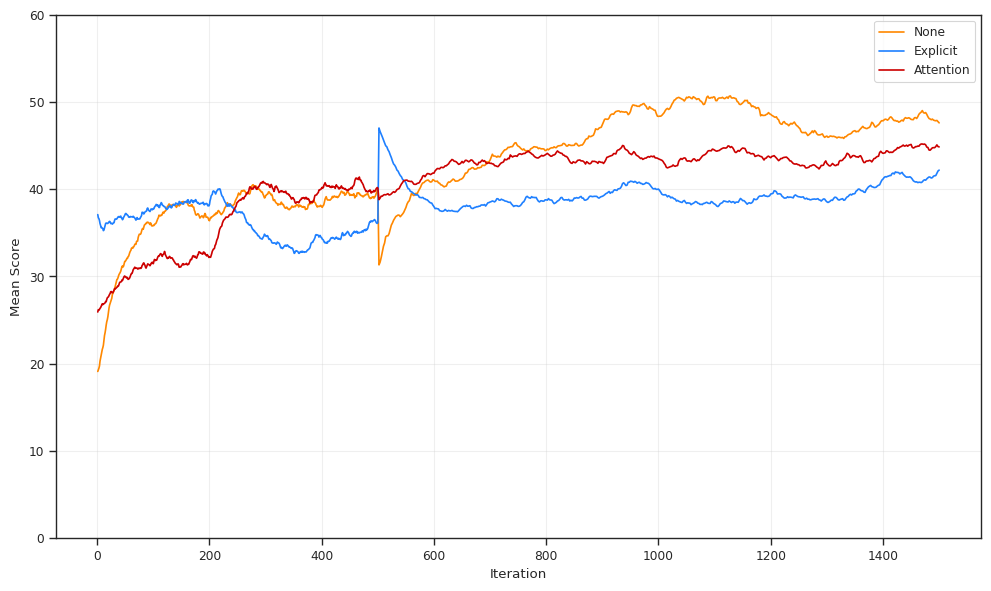

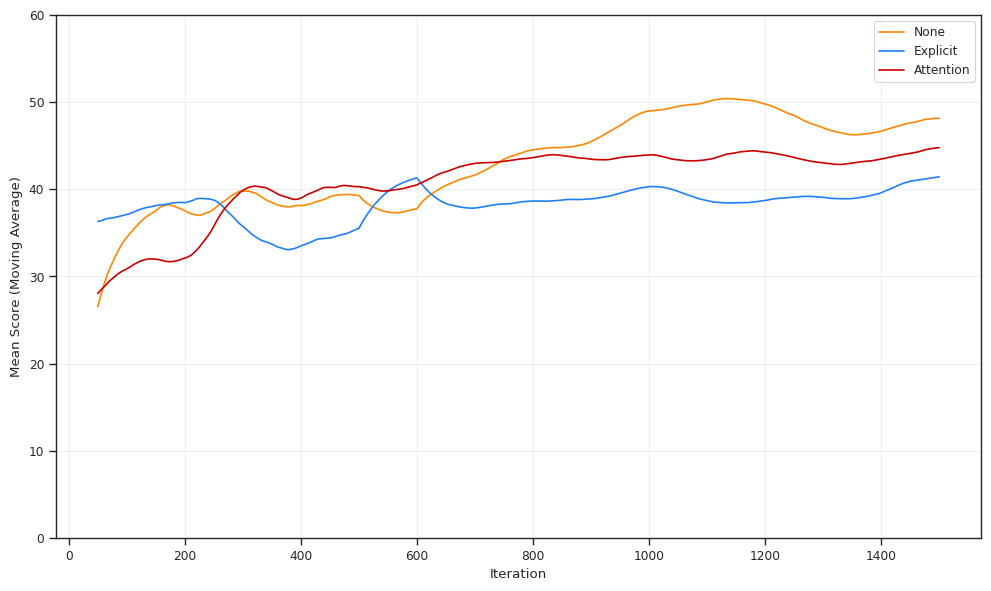

Average Episodes per Iteration: 10.67
Average Steps per Episode: 149.13
Average Steps per Iteration: 1591.43


In [5]:
# Load and merge training logs with clean unique indices

training_none_500_1000 = pd.read_csv('training_none_500_1000.csv')
training_none_500_1000['training_iteration'] += training_none_500_1000['training_iteration'] + 500

training_copy_500_1000 = pd.read_csv('training_copy_500_1000.csv')
training_copy_500_1000['training_iteration'] += training_copy_500_1000['training_iteration'] + 500

training_attention_500_1000 = pd.read_csv('training_attention_500_1000.csv')
training_attention_500_1000['training_iteration'] += training_attention_500_1000['training_iteration'] + 500

training_none = pd.concat(
    [pd.read_csv('training_none_0_500.csv'), training_none_500_1000],
    ignore_index=True
)
training_copy = pd.concat(
    [pd.read_csv('training_copy_0_500.csv'), training_copy_500_1000],
    ignore_index=True
)
training_attention = pd.concat(
    [pd.read_csv('training_attention_0_500.csv'), training_attention_500_1000],
    ignore_index=True
)

# training_none = pd.read_csv('training_none_0_1000.csv')
# training_copy = pd.read_csv('training_copy_0_1000.csv')
# training_attention = pd.read_csv('training_attention_0_1000.csv')

palette_map = {"None": PALETTE[0], "Explicit": PALETTE[1], "Attention": PALETTE[2]}

# Raw training curves
plt.figure(figsize=(10, 6))
sns.lineplot(data=training_none, x='training_iteration', y='env_runners/red_team_score_mean', label='None', color=palette_map["None"])
sns.lineplot(data=training_copy, x='training_iteration', y='env_runners/red_team_score_mean', label='Explicit', color=palette_map["Explicit"])
sns.lineplot(data=training_attention, x='training_iteration', y='env_runners/red_team_score_mean', label='Attention', color=palette_map["Attention"])
plt.xlabel('Iteration')
plt.ylabel('Mean Score')
plt.ylim(0, 60)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig('training_graph.pdf', dpi=300)
plt.show()

# Moving-average curves
window_size = 50
plt.figure(figsize=(10, 6))
sns.lineplot(data=training_none, x='training_iteration', y=training_none['env_runners/red_team_score_mean'].rolling(window_size).mean(), label='None', color=palette_map["None"])
sns.lineplot(data=training_copy, x='training_iteration', y=training_copy['env_runners/red_team_score_mean'].rolling(window_size).mean(), label='Explicit', color=palette_map["Explicit"])
sns.lineplot(data=training_attention, x='training_iteration', y=training_attention['env_runners/red_team_score_mean'].rolling(window_size).mean(), label='Attention', color=palette_map["Attention"])
plt.xlabel('Iteration')
plt.ylabel('Mean Score (Moving Average)')
plt.ylim(0, 60)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Calculate average episodes per iteration and average steps per episode and iteration for all three architectures combined
total_iterations = sum([training_none['training_iteration'].max(), training_copy['training_iteration'].max(), training_attention['training_iteration'].max()])
total_episodes = sum([training_none['env_runners/num_episodes_lifetime'].max(), training_copy['env_runners/num_episodes_lifetime'].max(), training_attention['env_runners/num_episodes_lifetime'].max()])
total_steps = sum([training_none['env_runners/num_env_steps_sampled_lifetime'].max(), training_copy['env_runners/num_env_steps_sampled_lifetime'].max(), training_attention['env_runners/num_env_steps_sampled_lifetime'].max()])


episodes_per_iteration = total_episodes / total_iterations
steps_per_episode = total_steps / total_episodes
steps_per_iteration = total_steps / total_iterations

print(f"Average Episodes per Iteration: {episodes_per_iteration:.2f}")
print(f"Average Steps per Episode: {steps_per_episode:.2f}")
print(f"Average Steps per Iteration: {steps_per_iteration:.2f}")



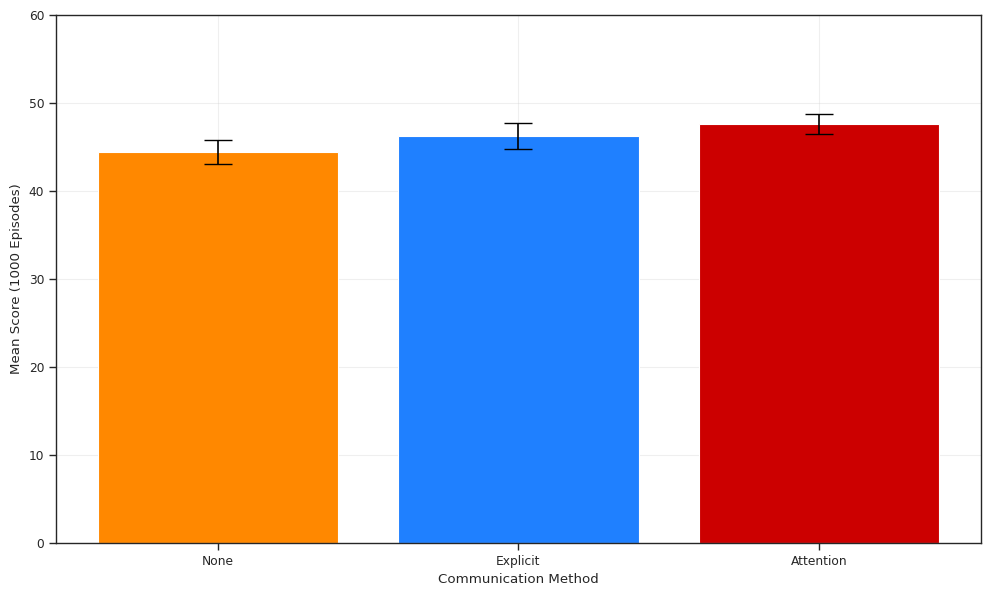

Kruskal-Wallis None vs Explicit: p = 0.0273
Kruskal-Wallis None vs Attention: p = 0.0019
Kruskal-Wallis Explicit vs Attention: p = 0.0585


In [6]:
# Calculate mean and std for each architecture

training_results = pd.read_csv('training_results.csv')
training_df = pd.DataFrame({
    "Architecture": ["None"] * len(training_results) + ["Explicit"] * len(training_results) + ["Attention"] * len(training_results),
    "Score": pd.concat([training_results['none'], training_results['copy'], training_results['attention']], ignore_index=True)
})

means = training_df.groupby('Architecture')['Score'].mean()
stds = training_df.groupby('Architecture')['Score'].std()

# Reorder to: None, Explicit, Attention
order = ['None', 'Explicit', 'Attention']
means = means.reindex(order)
stds = stds.reindex(order)

# Use notebook palette
bar_colors = [PALETTE[0], PALETTE[1], PALETTE[2]]  # None, Explicit, Attention

# Create bar chart with error bars
plt.figure(figsize=(10, 6))
plt.bar(
    means.index,
    means.values,
    yerr=stds.values,
    capsize=10,
    color=bar_colors
)
plt.ylabel('Mean Score (1000 Episodes)')
plt.xlabel('Communication Method')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.ylim(0, 60)
plt.savefig('training_averages_n_8.pdf', dpi=300)
plt.show()

# Run Kruskal-Wallis tests for statistical significance
none_scores = training_results['none']
copy_scores = training_results['copy']
attn_scores = training_results['attention']
_, p_none_copy = kruskal(none_scores, copy_scores)
_, p_none_attn = kruskal(none_scores, attn_scores)
_, p_copy_attn = kruskal(copy_scores, attn_scores)
print(f"Kruskal-Wallis None vs Explicit: p = {p_none_copy:.4f}")
print(f"Kruskal-Wallis None vs Attention: p = {p_none_attn:.4f}")
print(f"Kruskal-Wallis Explicit vs Attention: p = {p_copy_attn:.4f}")
